# 01 - Exploratory Data Analysis

This notebook performs a comprehensive EDA on the **Lung Cancer Survey** dataset (559 rows × 16 columns).

**Goals:**
- Inspect dataset structure, data types, missing values
- Analyse class distribution (LUNG_CANCER: YES / NO)
- Univariate & bivariate visualisations

In [1]:
# 1) Imports and display settings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

pd.set_option('display.max_columns', 100)
pd.set_option('display.width', 160)
sns.set(style='whitegrid')

In [2]:
# 2) Load dataset
DATA_PATH = Path('..') / 'data' / 'raw' / 'survey lung cancer.csv'
print('Loading', DATA_PATH)
df = pd.read_csv(DATA_PATH)
# strip column whitespace if present
df.columns = [c.strip() for c in df.columns]
print('Shape:', df.shape)
print('\nColumns:')
print(list(df.columns))

# show sample rows
df.head()

Loading ../data/raw/survey lung cancer.csv
Shape: (559, 16)

Columns:
['GENDER', 'AGE', 'SMOKING', 'YELLOW_FINGERS', 'ANXIETY', 'PEER_PRESSURE', 'CHRONIC DISEASE', 'FATIGUE', 'ALLERGY', 'WHEEZING', 'ALCOHOL CONSUMING', 'COUGHING', 'SHORTNESS OF BREATH', 'SWALLOWING DIFFICULTY', 'CHEST PAIN', 'LUNG_CANCER']


,GENDER,AGE,SMOKING,YELLOW_FINGERS,ANXIETY,PEER_PRESSURE,CHRONIC DISEASE,FATIGUE,ALLERGY,WHEEZING,ALCOHOL CONSUMING,COUGHING,SHORTNESS OF BREATH,SWALLOWING DIFFICULTY,CHEST PAIN,LUNG_CANCER
0,M,69,1,2,2,1,1,2,1,2,2,2,2,2,2,YES
1,M,74,2,1,1,1,2,2,2,1,1,1,2,2,2,YES
2,F,59,1,1,1,2,1,2,1,2,1,2,2,1,2,NO
3,M,63,2,2,2,1,1,1,1,1,2,1,1,2,2,NO
4,F,63,1,2,1,1,1,1,1,2,1,2,2,1,1,NO


In [3]:
# 3) Dtypes and missing values
print(df.dtypes)
print('\nMissing values:')
print(df.isnull().sum())

GENDER                   object
AGE                       int64
SMOKING                   int64
YELLOW_FINGERS            int64
ANXIETY                   int64
PEER_PRESSURE             int64
CHRONIC DISEASE           int64
FATIGUE                   int64
ALLERGY                   int64
WHEEZING                  int64
ALCOHOL CONSUMING         int64
COUGHING                  int64
SHORTNESS OF BREATH       int64
SWALLOWING DIFFICULTY     int64
CHEST PAIN                int64
LUNG_CANCER              object
dtype: object

Missing values:
GENDER                   0
AGE                      0
SMOKING                  0
YELLOW_FINGERS           0
ANXIETY                  0
PEER_PRESSURE            0
CHRONIC DISEASE          0
FATIGUE                  0
ALLERGY                  0
WHEEZING                 0
ALCOHOL CONSUMING        0
COUGHING                 0
SHORTNESS OF BREATH      0
SWALLOWING DIFFICULTY    0
CHEST PAIN               0
LUNG_CANCER              0
dtype: int64


In [4]:
print('\nValue counts for LUNG_CANCER:')
print(df['LUNG_CANCER'].value_counts(dropna=False))


Value counts for LUNG_CANCER:
LUNG_CANCER
YES    488
NO      71
Name: count, dtype: int64


In [5]:
# 4) Unique values per feature
for col in df.columns:
    print(f"{col}: {df[col].nunique()} unique : {df[col].unique()[:10]}")

GENDER: 2 unique : ['M' 'F']
AGE: 39 unique : [69 74 59 63 75 52 51 68 53 61]
SMOKING: 2 unique : [1 2]
YELLOW_FINGERS: 2 unique : [2 1]
ANXIETY: 2 unique : [2 1]
PEER_PRESSURE: 2 unique : [1 2]
CHRONIC DISEASE: 2 unique : [1 2]
FATIGUE: 2 unique : [2 1]
ALLERGY: 2 unique : [1 2]
WHEEZING: 2 unique : [2 1]
ALCOHOL CONSUMING: 2 unique : [2 1]
COUGHING: 2 unique : [2 1]
SHORTNESS OF BREATH: 2 unique : [2 1]
SWALLOWING DIFFICULTY: 2 unique : [2 1]
CHEST PAIN: 2 unique : [2 1]
LUNG_CANCER: 2 unique : ['YES' 'NO']


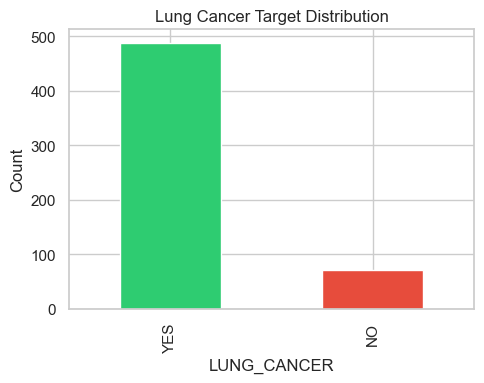

In [6]:
# 5) Class distribution bar chart
fig, ax = plt.subplots(figsize=(5,4))
df['LUNG_CANCER'].value_counts().plot(kind='bar', color=['#2ecc71','#e74c3c'], ax=ax)
ax.set_title('Lung Cancer Target Distribution')
ax.set_ylabel('Count')
plt.tight_layout()
plt.savefig('../results/class_distribution.png', dpi=150)
plt.show()

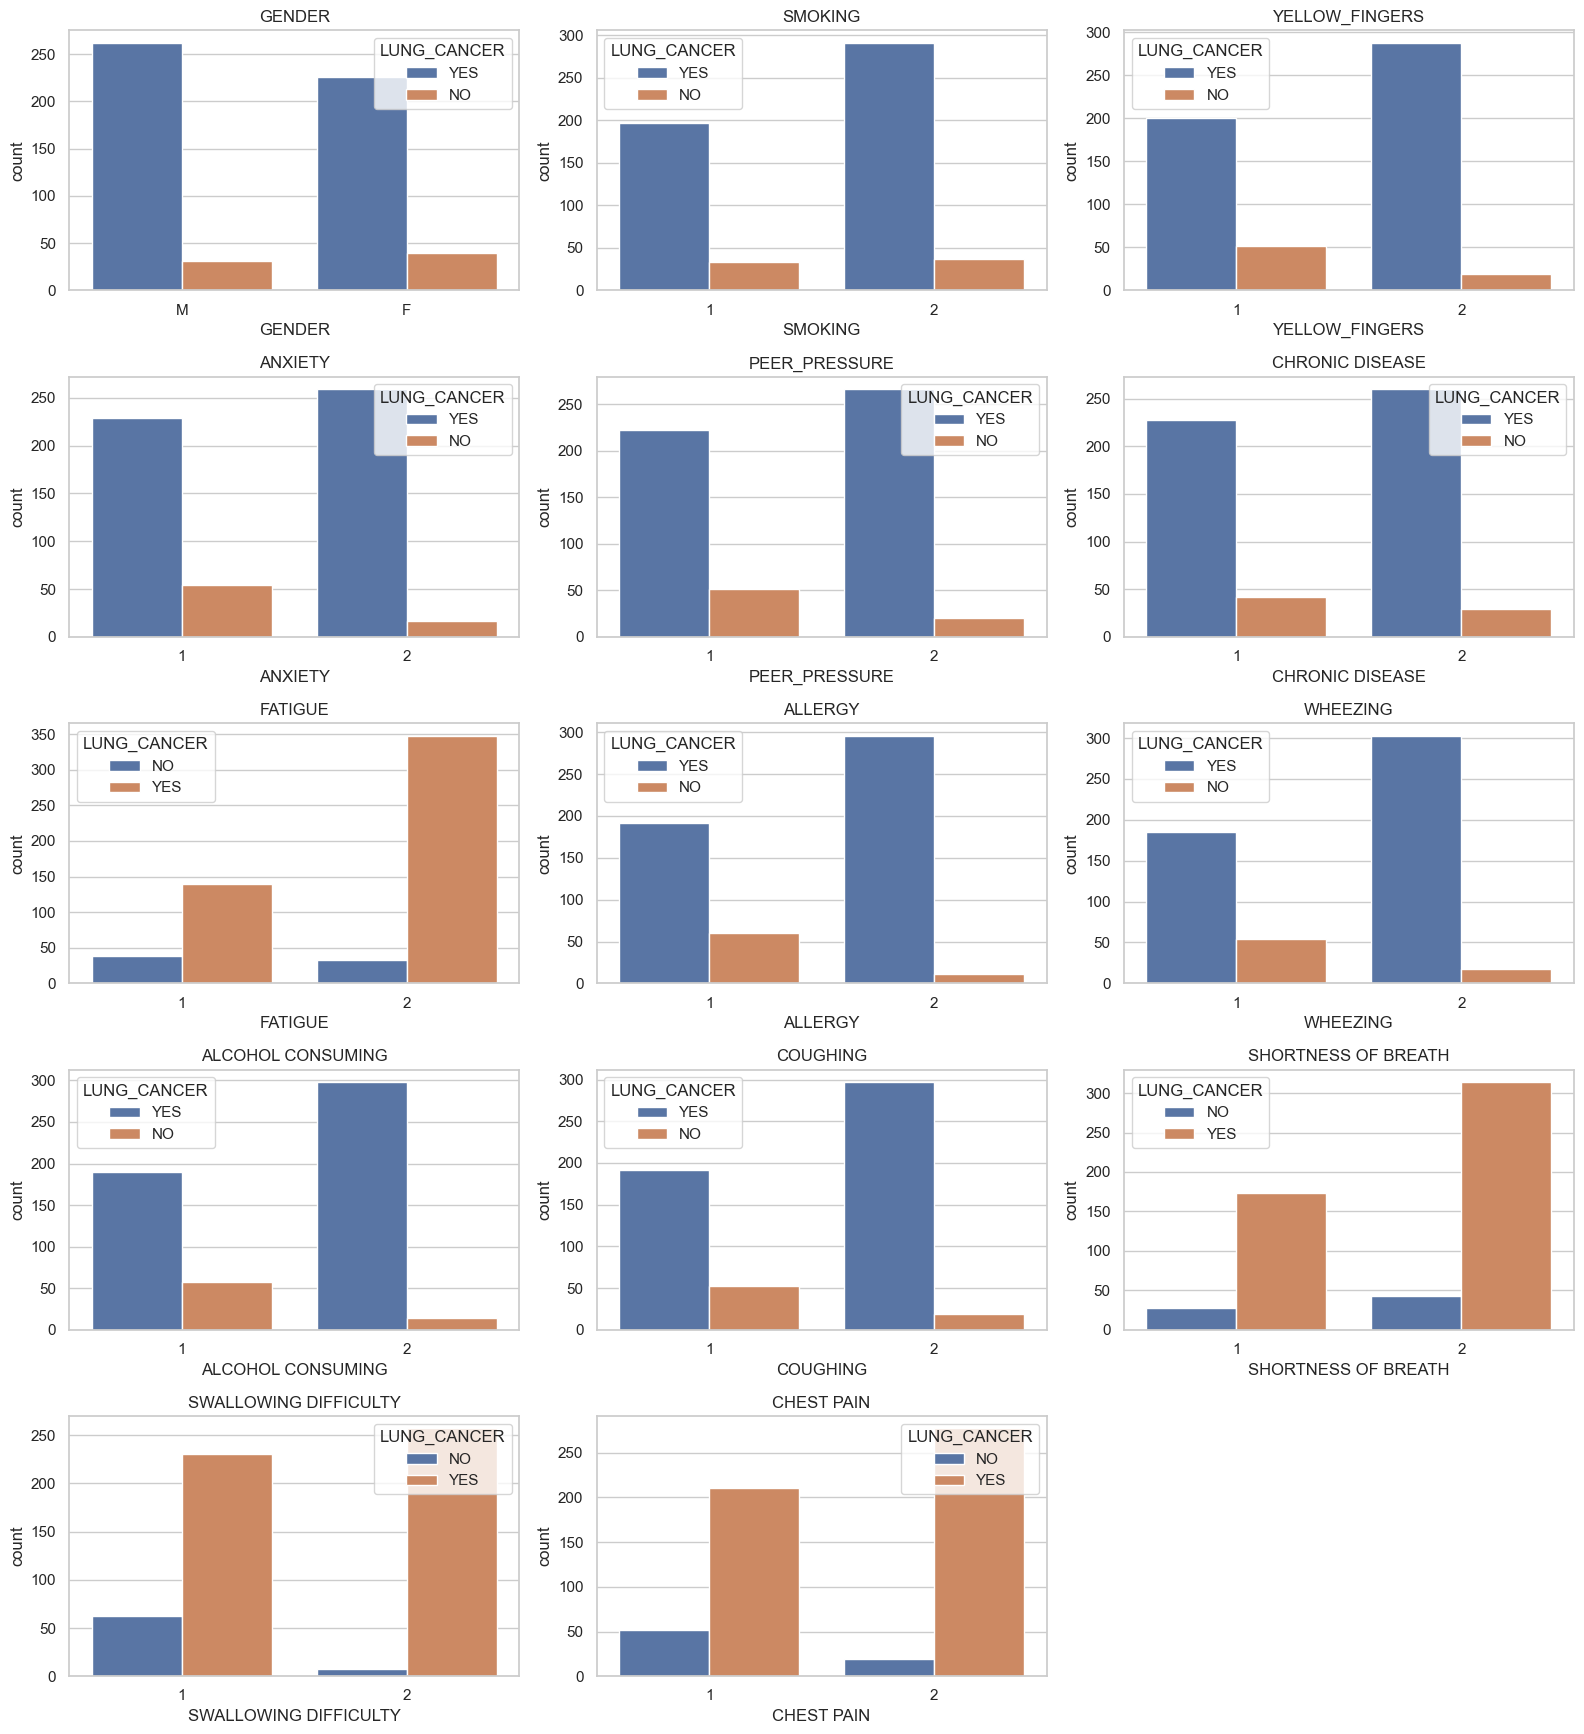

In [7]:
# 6) Countplots for binary features grouped by LUNG_CANCER
binary_cols = [c for c in df.columns if c not in ['AGE','LUNG_CANCER']]
n_cols = 3
n_rows = (len(binary_cols) + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 3.5 * n_rows))
axes = axes.flatten()
for i, col in enumerate(binary_cols):
    sns.countplot(data=df, x=col, hue='LUNG_CANCER', ax=axes[i])
    axes[i].set_title(col)
for j in range(len(binary_cols), len(axes)):
    axes[j].set_visible(False)
plt.tight_layout()
plt.savefig('../results/feature_countplots.png', dpi=150)
plt.show()

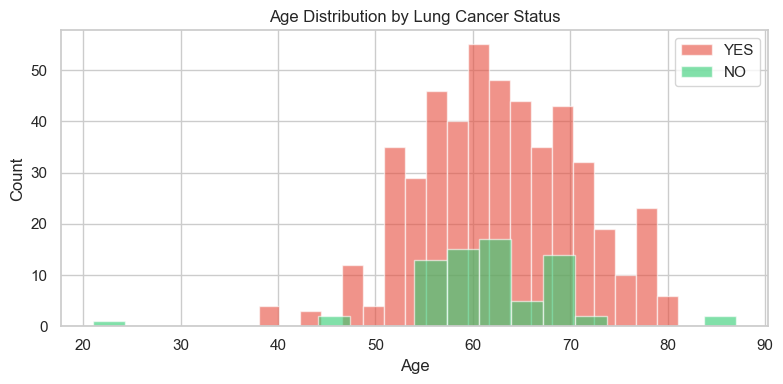

In [8]:
# 7) Age distribution by LUNG_CANCER
fig, ax = plt.subplots(figsize=(8, 4))
df[df['LUNG_CANCER']=='YES']['AGE'].hist(alpha=0.6, label='YES', bins=20, ax=ax, color='#e74c3c')
df[df['LUNG_CANCER']=='NO']['AGE'].hist(alpha=0.6, label='NO', bins=20, ax=ax, color='#2ecc71')
ax.set_xlabel('Age')
ax.set_ylabel('Count')
ax.set_title('Age Distribution by Lung Cancer Status')
ax.legend()
plt.tight_layout()
plt.savefig('../results/age_distribution.png', dpi=150)
plt.show()

## EDA Summary

| Aspect | Details |
|---|---|
| **Rows × Columns** | 559 × 16 (15 features + 1 target) |
| **Target** | `LUNG_CANCER` — YES: 488 (87.3%), NO: 71 (12.7%) |
| **Missing values** | None across all columns |
| **Data types** | `GENDER` (object: M/F), `AGE` (int64, 39 unique values), `LUNG_CANCER` (object: YES/NO), remaining 13 features (int64, binary 1/2) |

**Key Findings:**
- **Class imbalance** — the dataset is heavily skewed toward YES (≈ 7 : 1 ratio), which must be handled during modelling (e.g. `class_weight='balanced'`, `scale_pos_weight`).
- **No missing data** — no imputation needed.
- **Binary encoding** — the 13 symptom/lifestyle features use 1 = No, 2 = Yes; these will be mapped to 0/1 in preprocessing.
- **GENDER** — categorical (M/F), to be label-encoded (M -1, F -0).
- **AGE** — thecontinuous feature will that will be scaled (StandardScaler) for distance-based models like kNN and Logistic Regression.
- **Feature–target patterns** — the countplots above show that most binary features have a higher proportion of `YES` cases, but some (e.g. ALLERGY, WHEEZING, PEER_PRESSURE) show a clearer separation and may be more predictive.